# Phase 2: MRI Preprocessing

In [1]:
# Setting the directories

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

IMG_SIZE = (128, 128)

LABEL_ORDER = ['Non-Demented', 'Very Mild Demented', 'Mild Demented', 'Moderate Demented']

_cwd = os.path.abspath(os.getcwd())
BASE_DIR = os.path.dirname(_cwd) if os.path.basename(_cwd) == 'notebooks' else _cwd

PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
PLOTS_DIR     = os.path.join(BASE_DIR, 'outputs', 'plots')

In [2]:
# Loading MRI slices

# Reading metadata produced in Phase 1
df = pd.read_csv(os.path.join(PROCESSED_DIR, 'metadata_processed.csv'))

X_list = []
y_list = []

# Loading each refined PNG, applying grayscale normalisation, flattening to vector
for _, row in df.iterrows():
    img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
    if img is None:
        continue
    img = cv2.resize(img, IMG_SIZE).astype(np.float32) / 255.0
    X_list.append(img.flatten())
    y_list.append(row['dementia_stage_label'])

X = np.array(X_list)  # (n_samples, 16384)
y = np.array(y_list)

print(f'Feature matrix X : {X.shape}')
print(f'Label vector y   : {y.shape}')

Feature matrix X : (442, 16384)
Label vector y   : (442,)


In [3]:
# Saving feature arrays

np.save(os.path.join(PROCESSED_DIR, 'X.npy'), X)
np.save(os.path.join(PROCESSED_DIR, 'y.npy'), y)
print('Saved X.npy and y.npy')

Saved X.npy and y.npy


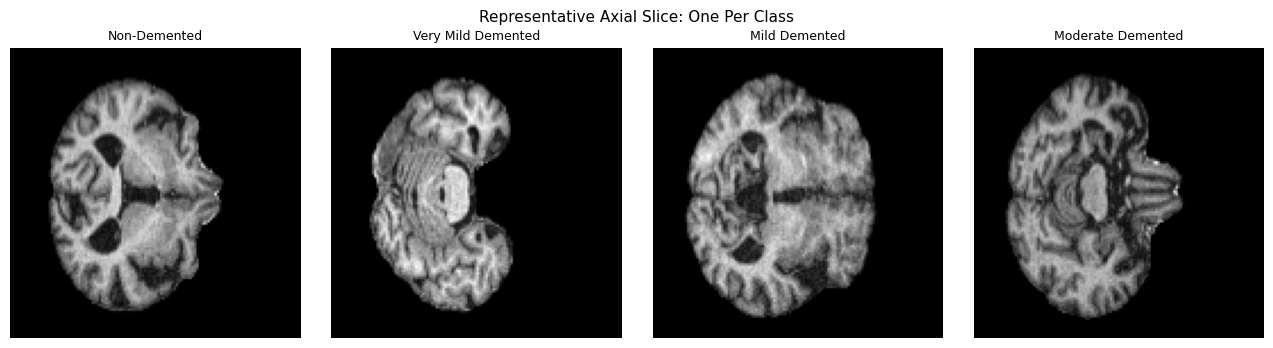

In [4]:
# Plotting sample MRI slices per class

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))

for ax, label in zip(axes, LABEL_ORDER):
    idx = np.where(y == label)[0][0]
    ax.imshow(X[idx].reshape(IMG_SIZE), cmap='gray')
    ax.set_title(label, fontsize=9)
    ax.axis('off')

plt.suptitle('Representative Axial Slice: One Per Class', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'sample_slices.png'), dpi=150)
plt.show()